In [17]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as pyplot

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [19]:
df = pd.read_csv('titanic_toy.csv')
df.head() 

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [20]:
df.isnull().mean()         # approx 5% data missing in 'Fare' column and 19.8% missing data on 'Age' column

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


<h3 style='color:blue'>Train-test split </h3>

In [22]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train.shape, X_test.shape

((668, 3), (223, 3))

<h2 style='color:brown'>Using Pandas</h2>

In [23]:
# creating 4 different columns in which missing values has been filled by : 
# 99 and -1 for 'Age' column 
# 999 and -1 for 'Fare' column 
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train["Age"].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train["Fare"].fillna(-1)

In [24]:
X_train.sample(5)

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
633,NaN,NaN,0,99.0,-1.0,999.0000,-1.0000
227,20.5,7.2500,0,20.5,20.5,7.2500,7.2500
194,44.0,NaN,0,44.0,44.0,999.0000,-1.0000
779,43.0,211.3375,1,43.0,43.0,211.3375,211.3375
437,24.0,18.7500,5,24.0,24.0,18.7500,18.7500


In [40]:
# variance - square of the distance of the point from the mean.
print("Original Age variable Variance :", X_train['Age'].var())
print("Age Variance after 99 Imutation:", X_train['Age_99'].var())
print("Age Variance after -1 Imutation:", X_train['Age_minus1'].var(), '\n')    
# Age has around 20% missing values, so significant variance skrinkage can be observed. 

print("Original Fare variable Variance :", X_train['Fare'].var())
print("Fare Variance after 999 Imutation:", X_train['Fare_999'].var())
print("Fare Variance after -1 Imutation:", X_train['Fare_minus1'].var())

# After applying arbitrary value imputation, the variance of the column 'changes',
# you have to observe that the variance should not increase/decrease drastically.

Original Age variable Variance : 209.90193932584322
Age Variance after 99 Imutation: 930.581444601351
Age Variance after -1 Imutation: 320.52995836842246 

Original Fare variable Variance : 2625.614945269419
Fare Variance after 999 Imutation: 51443.3804882111
Fare Variance after -1 Imutation: 2538.2291613296297


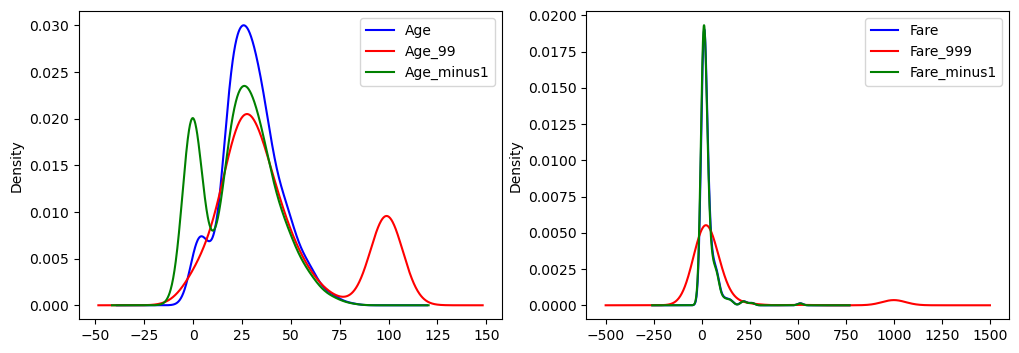

In [41]:
# Observe changes in the distribution of respective columns.

pyplot.figure(figsize=(12, 4))
pyplot.subplot(121)         # Age column
X_train['Age'].plot(kind='kde', color='blue', label='Age')
X_train['Age_99'].plot(kind='kde', color='red', label='Age_99')                # red 2 peaks due to 99 value imputation in 20% of missing places
X_train['Age_minus1'].plot(kind='kde', color='green', label='Age_minus1')      # green 2 peaks due to -1 value imputation in 20% of missing places
pyplot.legend()   # to show the labels in the kde plot

pyplot.subplot(122)         # Fare column
X_train['Fare'].plot(kind='kde', color='blue', label='Fare')                    # # original variable distribution
X_train['Fare_999'].plot(kind='kde', color='red', label='Fare_999')             # # variable imputed with 99 (arbitrary value)
X_train['Fare_minus1'].plot(kind='kde', color='green', label='Fare_minus1')     # # variable imputed with -1
pyplot.legend() 

pyplot.show()

# 'Fare' blue and green have almost same distribution.

<h3 style='color:blue'>Checking Correlation & Covariance</h3>

In [37]:
X_train.corr()        # ranges from -1 to 1.

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.109989,-0.297463,1.000000,1.000000,0.031853,0.104905
Fare,0.109989,1.000000,0.188900,-0.033328,0.135025,1.000000,1.000000
Family,-0.297463,0.188900,1.000000,-0.100289,-0.169670,0.020932,0.187596
Age_99,1.000000,-0.033328,-0.100289,1.000000,-0.316655,-0.024077,-0.029531
Age_minus1,1.000000,0.135025,-0.169670,-0.316655,1.000000,0.048851,0.127120
Fare_999,0.031853,1.000000,0.020932,-0.024077,0.048851,1.000000,0.069218
Fare_minus1,0.104905,1.000000,0.187596,-0.029531,0.127120,0.069218,1.000000


In [38]:
X_train.cov()        # no range limit

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,209.901939,87.427119,-6.406798,209.901939,209.901939,106.914441,81.446276
Fare,87.427119,2625.614945,16.579320,-52.330514,124.349312,2625.614945,2625.614945
Family,-6.406798,16.579320,2.838689,-5.154560,-5.117976,7.998955,15.923885
Age_99,209.901939,-52.330514,-5.154560,930.581445,-172.941008,-166.590779,-45.386037
Age_minus1,209.901939,124.349312,-5.117976,-172.941008,320.529958,198.367902,114.660130
Fare_999,106.914441,2625.614945,7.998955,-166.590779,198.367902,51443.380488,790.955648
Fare_minus1,81.446276,2625.614945,15.923885,-45.386037,114.660130,790.955648,2538.229161


<h3 style='color:blue'>Box-Plot to check for Outliers</h3>

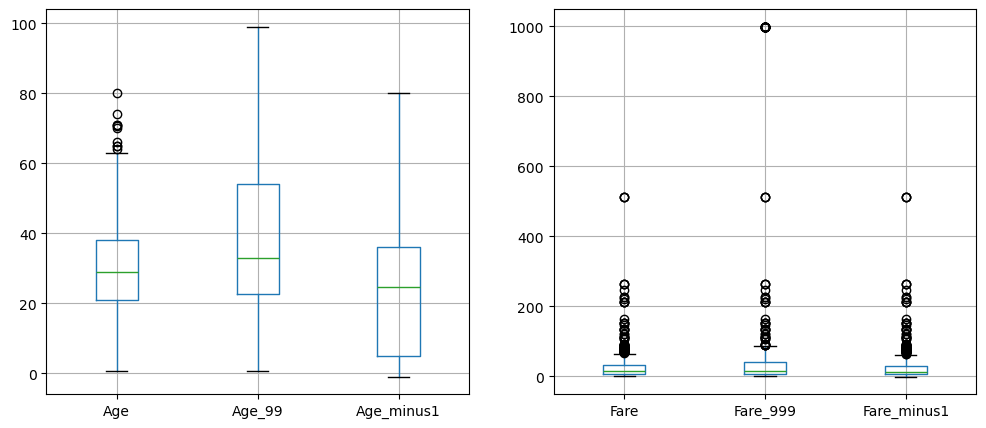

In [42]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(121)
X_train[['Age','Age_99','Age_minus1']].boxplot()         # IQR Changes 

pyplot.subplot(122)
X_train[['Fare','Fare_999','Fare_minus1']].boxplot()      # no major change in outliers observed.
pyplot.show()
# IQR - Inter Quatile Range

<h2 style='color:brown'> Using sklearn</h2>

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0) 
X_train.shape, X_test.shape

((668, 3), (223, 3))

In [59]:
# Filling Arbitrary value
imputer1 = SimpleImputer(strategy='constant', fill_value=99)       # for 'Age' column
imputer2 = SimpleImputer(strategy='constant', fill_value=999)      # for 'Fare' column

In [50]:
tnf = ColumnTransformer(transformers=[
                            ('tnf_age', imputer1, ['Age']),
                            ('tnf_fare', imputer2, ['Fare']),
                        ], 
                        remainder='passthrough'
)

In [51]:
X_train = tnf.fit_transform(X_train)
X_test = tnf.transform(X_test)     

In [52]:
X_train

array([[28.    ,  7.8958,  0.    ],
       [17.    ,  7.925 ,  6.    ],
       [30.    , 16.1   ,  1.    ],
       ...,
       [99.    ,  7.7333,  0.    ],
       [36.    , 17.4   ,  1.    ],
       [60.    , 39.    ,  2.    ]])

In [53]:
tnf.named_transformers_

{'tnf_age': SimpleImputer(fill_value=99, strategy='constant'),
 'tnf_fare': SimpleImputer(fill_value=999, strategy='constant'),
 'remainder': FunctionTransformer(accept_sparse=True, check_inverse=False,
                     feature_names_out='one-to-one')}

In [57]:
tnf.named_transformers_['tnf_age'].statistics_    # filling by arbitrary value '99'

array([99.])

In [58]:
tnf.named_transformers_['tnf_fare'].statistics_    # filling by arbitrary value '999'

array([999.])